In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# 读取数据
tabular_detail = pd.read_excel(
    "/data/coding/wsad/new_wzb/WSADBench/results/classical_bags_inexact/summary/summary_delnan.xlsx",
    sheet_name="详细结果",
    dtype={'rla': 'object', 'eln': 'object'}
)

# ---- 修复点 1：自动转换 rla 类型 ----
# 尝试转换为 float（失败则忽略）
tabular_detail["rla"] = pd.to_numeric(tabular_detail["rla"], errors="coerce")

# 需要的 rla 值
rlas = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]

# 过滤
tabular_detail = tabular_detail[tabular_detail["rla"].isin(rlas)]

# ---- 修复点 2：重新 groupby ----
rla_draw = tabular_detail.groupby(["rla", "model"]).agg(
    {
        "aucroc": "mean",
        "aucpr": "mean",
    }
).reset_index()

# ---- 修复点 3：自动提取模型名 ----
available_models = rla_draw["model"].unique().tolist()
print("可用模型名：", available_models)

# 如果你确实想保留你的手动列表，则需要交集
model_names = ["RoSAS","DeepSAD", "DevNet", "PReNet", "REPEN", "FEAWAD","NTL","CatB","XGBOD","GANomaly","PUMA","Sultani","ZhongGCNAD"]
model_names = [m for m in model_names if m in available_models]

print("实际绘图模型：", model_names)

# ---- 修复点 4：如果为空提示 ----
if len(model_names) == 0:
    raise ValueError("❌ 手动指定的 model_names 在数据中不存在，请检查模型名字！")

# ---- 绘图 ----
fig, ax = plt.subplots(1, 1, figsize=(9, 6), dpi=500)

markers = ['o', 's', 'v', '^', '<', '>', 'D', 'p', '*', 'h', 'H', '+', 'x', 'd']
markers = (markers * (len(model_names) // len(markers) + 1))[:len(model_names)]

for model_name, marker in zip(model_names, markers):
    df_model = rla_draw[rla_draw["model"] == model_name]

    sns.lineplot(
        data=df_model,
        x="rla",
        y="aucroc",
        label=model_name,
        ax=ax,
        marker=marker,
    )

ax.set_xticks(rlas)
ax.set_xticklabels(rlas)
plt.grid()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/data/coding/wsad/new_wzb/WSADBench/results/classical_bags_inexact/summary/summary_delnan.xlsx'

可用模型名： ['AABiGAN', 'CatB', 'DeepSAD', 'DevNet', 'FEAWAD', 'GANomaly', 'NTL', 'PReNet', 'PUMA', 'REPEN', 'RoSAS', 'Sultani', 'XGBOD', 'ZhongGCNAD']


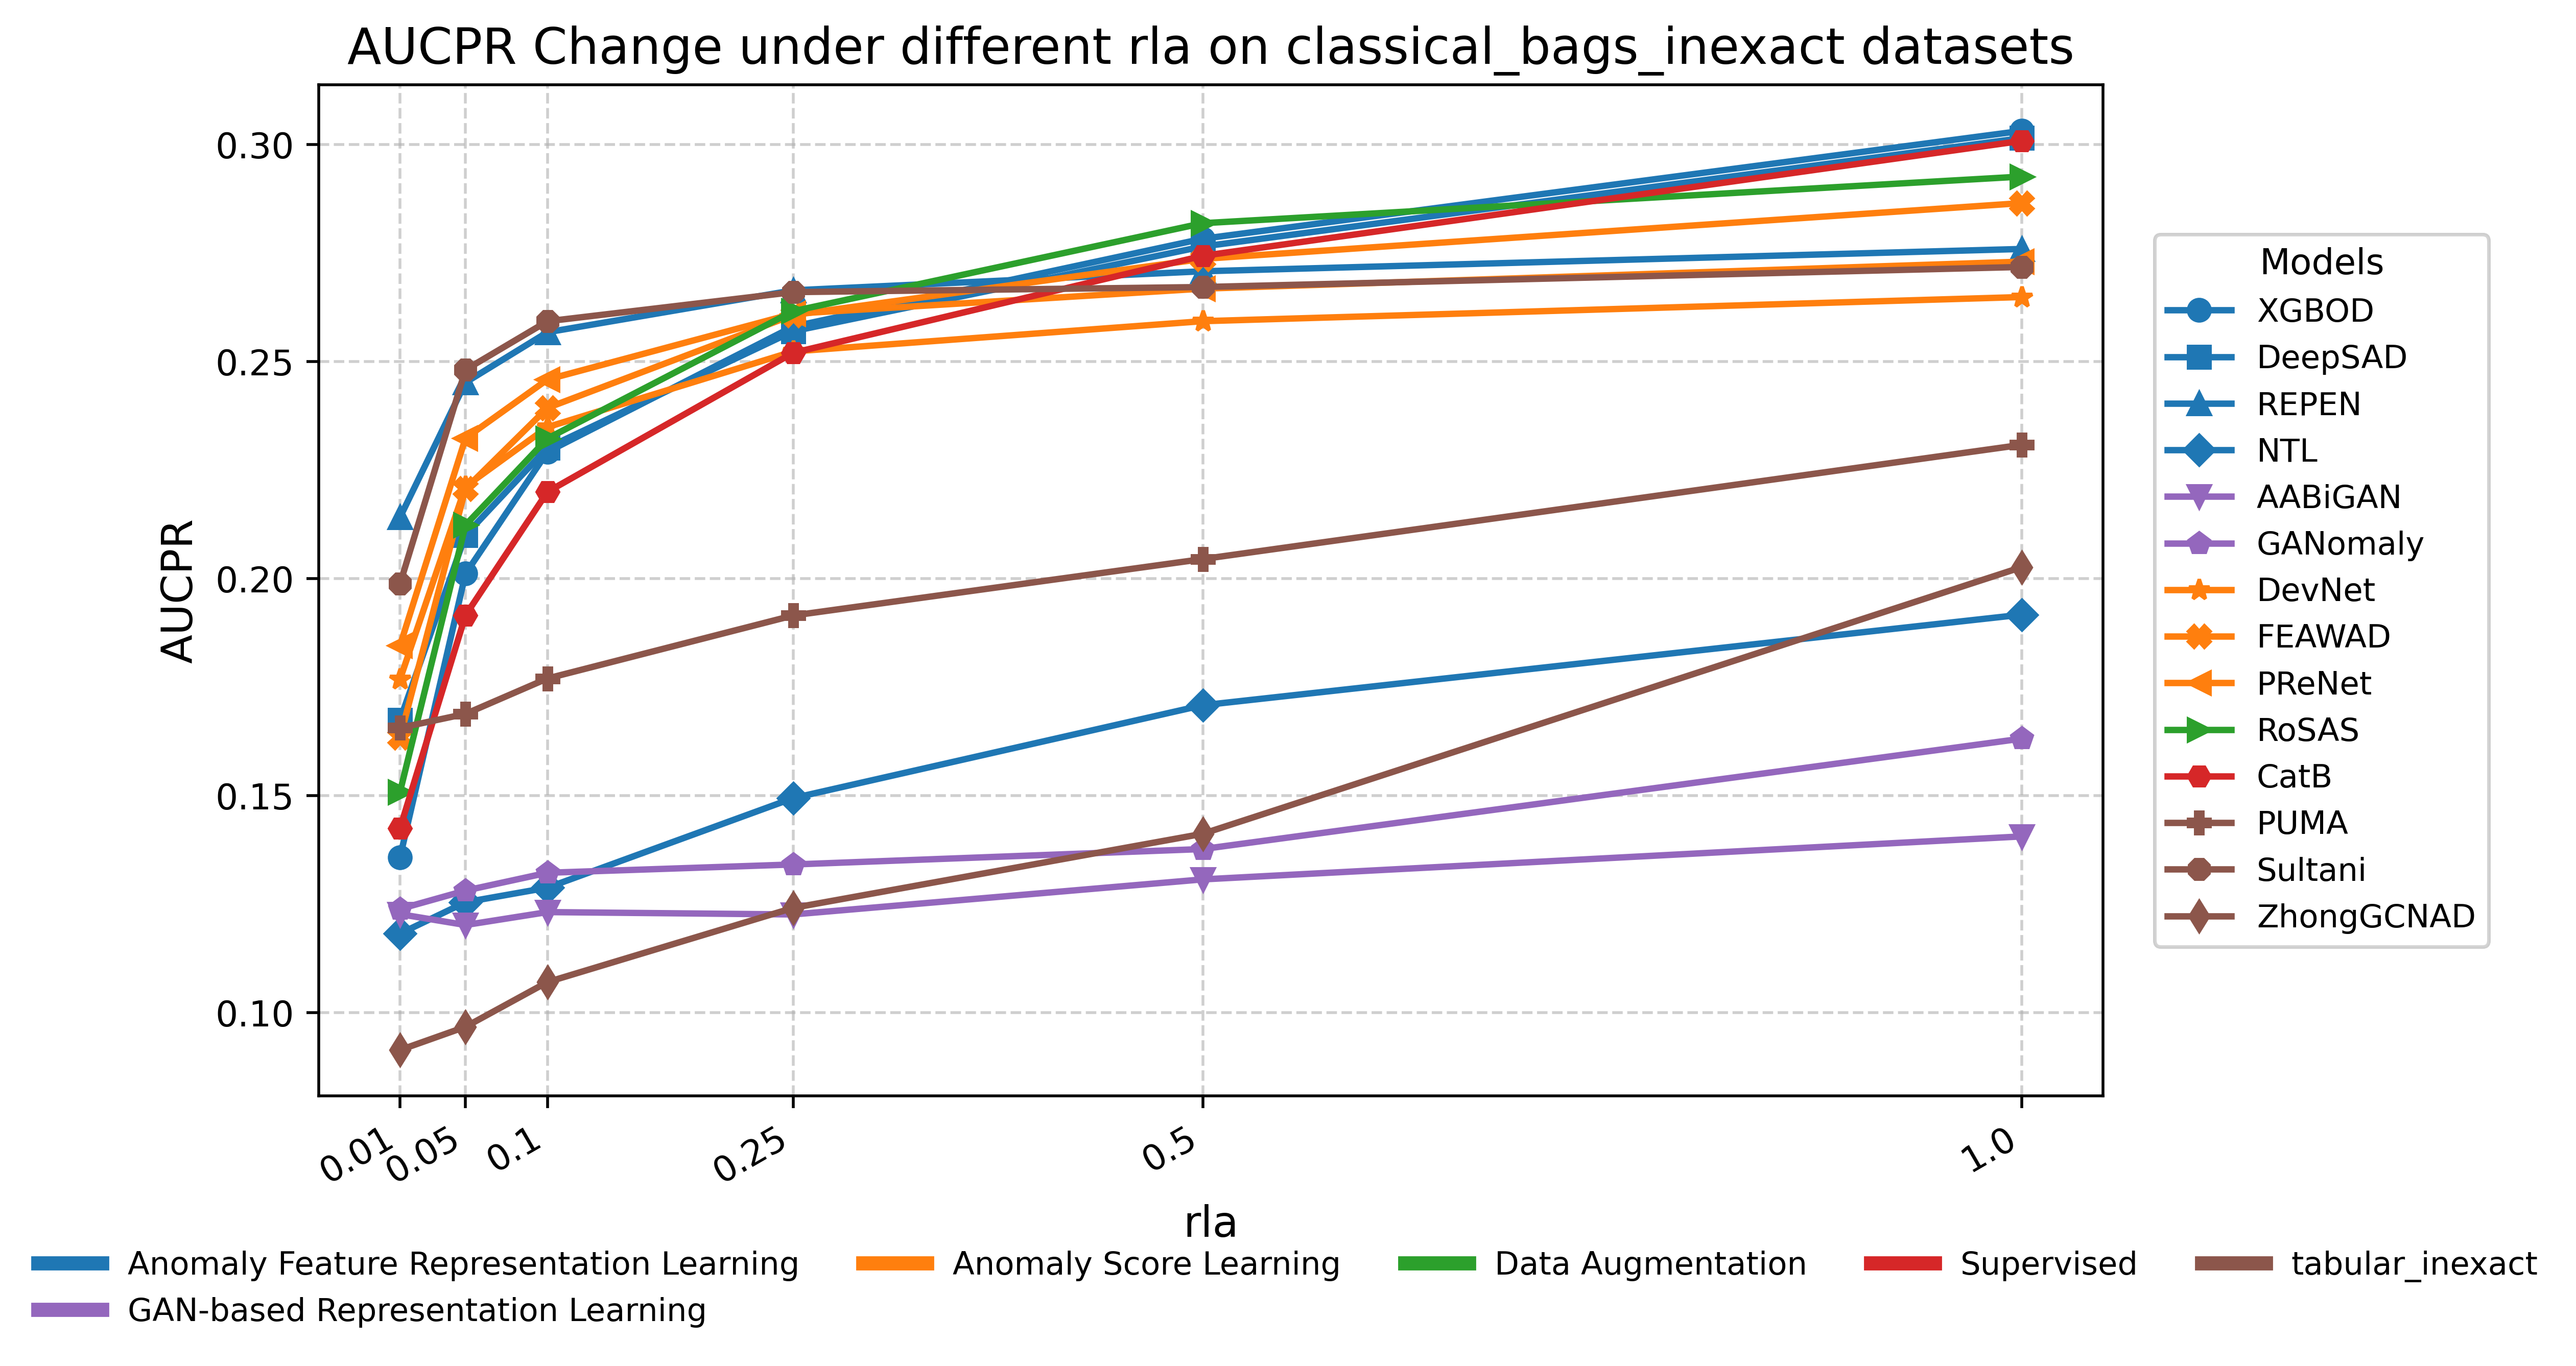

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import itertools
from matplotlib.lines import Line2D
from sympy import rotations

# 读取数据
tabular_detail = pd.read_excel(
    "C:/Users/吴振波/Desktop/myproject/WSADBenchmark/dataset_all/tabular_inexact/summary_delnan.xlsx",
    sheet_name="详细结果",
    dtype={'rla': 'object', 'eln': 'object'}
)

# ---- 修复点 1：自动转换 rla 类型 ----
tabular_detail["rla"] = pd.to_numeric(tabular_detail["rla"], errors="coerce")

# 需要的 rla 值
rlas = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
tabular_detail = tabular_detail[tabular_detail["rla"].isin(rlas)]

# ---- 修复点 2：groupby ----
rla_draw = tabular_detail.groupby(["rla", "model"]).agg(
    {"aucroc": "mean", "aucpr": "mean"}
).reset_index()

available_models = rla_draw["model"].unique().tolist()
print("可用模型名：", available_models)

# --------------------------------------------------------------------------------
#                                分组区域
# --------------------------------------------------------------------------------
groups = {
    "Anomaly Feature Representation Learning": ["XGBOD", "DeepSAD", "REPEN", "DualMGAN", "NTL"],
    "GAN-based Representation Learning": ["AABiGAN", "GANomaly"],
    "Anomaly Score Learning": ["DevNet", "FEAWAD", "PReNet"],
    "Data Augmentation": ["RoSAS"],
    "Supervised": ["XGB", "CatB", "FTTransformer"],
    "tabular_inexact":["PUMA","Sultani","ZhongGCNAD"],
    "Deep learning tabular model":["TabMCls","TabPFN"]

}

# 第三步：颜色分组（每类一颜色）
group_colors = {
    "Anomaly Feature Representation Learning": "#1f77b4",
    "GAN-based Representation Learning": "#9467bd",
    "Anomaly Score Learning": "#ff7f0e",
    "Data Augmentation": "#2ca02c",
    "Supervised": "#d62728",
    "tabular_inexact": "#8c564b",
    "Deep learning tabular model": "#e377c2"
}

# ------------ marker 自动循环 ----------------
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', '<', '>', 'H', 'P', '8', 'd', 'h']
marker_cycle = itertools.cycle(markers)

# --------------------------------------------------------------------------------
#                              绘图区域
# --------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(11, 6), dpi=500)

model_handles = []

# 循环画线：同类同色，每模型不同 marker
for group_name, models in groups.items():
    color = group_colors[group_name]

    for model in models:
        if model not in available_models:
            continue

        df_sub = rla_draw[rla_draw["model"] == model]
        if df_sub.empty:
            continue

        marker = next(marker_cycle)
        line, = ax.plot(
            df_sub["rla"],
            df_sub["aucpr"],             # ****** 你这里想画 aucroc，我保持一致 ******
            marker=marker,
            markersize=6,
            color=color,
            linewidth=1.8,
            label=model
        )
        model_handles.append(line)

# --------------------------------------------------------------------------------
#                                X轴美化
# --------------------------------------------------------------------------------
ax.set_xticks(rlas)
ax.set_xticklabels(rlas, rotation=30, ha='right')
ax.set_xlabel("rla", fontsize=12)
ax.set_ylabel("AUCPR", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title("AUCPR Change under different rla on classical_bags_inexact datasets", fontsize=14)

# --------------------------------------------------------------------------------
#    右侧：模型名图例（marker+颜色）  
#    底部：模型类别图例（仅颜色线段）  
# --------------------------------------------------------------------------------

plt.subplots_adjust(right=0.76, bottom=0.22)

# ---- (1) 右侧 “模型名” 图例 ----
model_legend = ax.legend(
    handles=model_handles,
    title="Models",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    bbox_transform=ax.transAxes,
    fontsize=9,
    title_fontsize=10,
    frameon=True,
)

# ---- (2) 底部 “类别图例” ----
group_handles = [
    Line2D([0], [0], color=color, lw=4, label=group)
    for group, color in group_colors.items()
]

fig.legend(
    handles=group_handles,
    loc='lower center',
    bbox_to_anchor=(0.47, 0.05),
    ncol=5,
    fontsize=9,
    frameon=False
)

ax.add_artist(model_legend)

plt.show()


In [2]:
rla_draw

,rla,model,aucroc,aucpr
0,0.01,AABiGAN,0.642101,0.320681
1,0.01,CatB,0.838319,0.520420
2,0.01,DeepSAD,0.755714,0.377297
3,0.01,DevNet,0.802378,0.555743
4,0.01,DevNet_BCE,0.805742,0.551644
...,...,...,...,...
110,1.00,PReNet,0.918360,0.729355
111,1.00,PReNet_LayerNorm,0.927794,0.775222
112,1.00,RoSAS,0.940530,0.810784
113,1.00,XGB,0.967746,0.857196


/tmp/ipykernel_2855601/1030166753.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2855601/1030166753.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


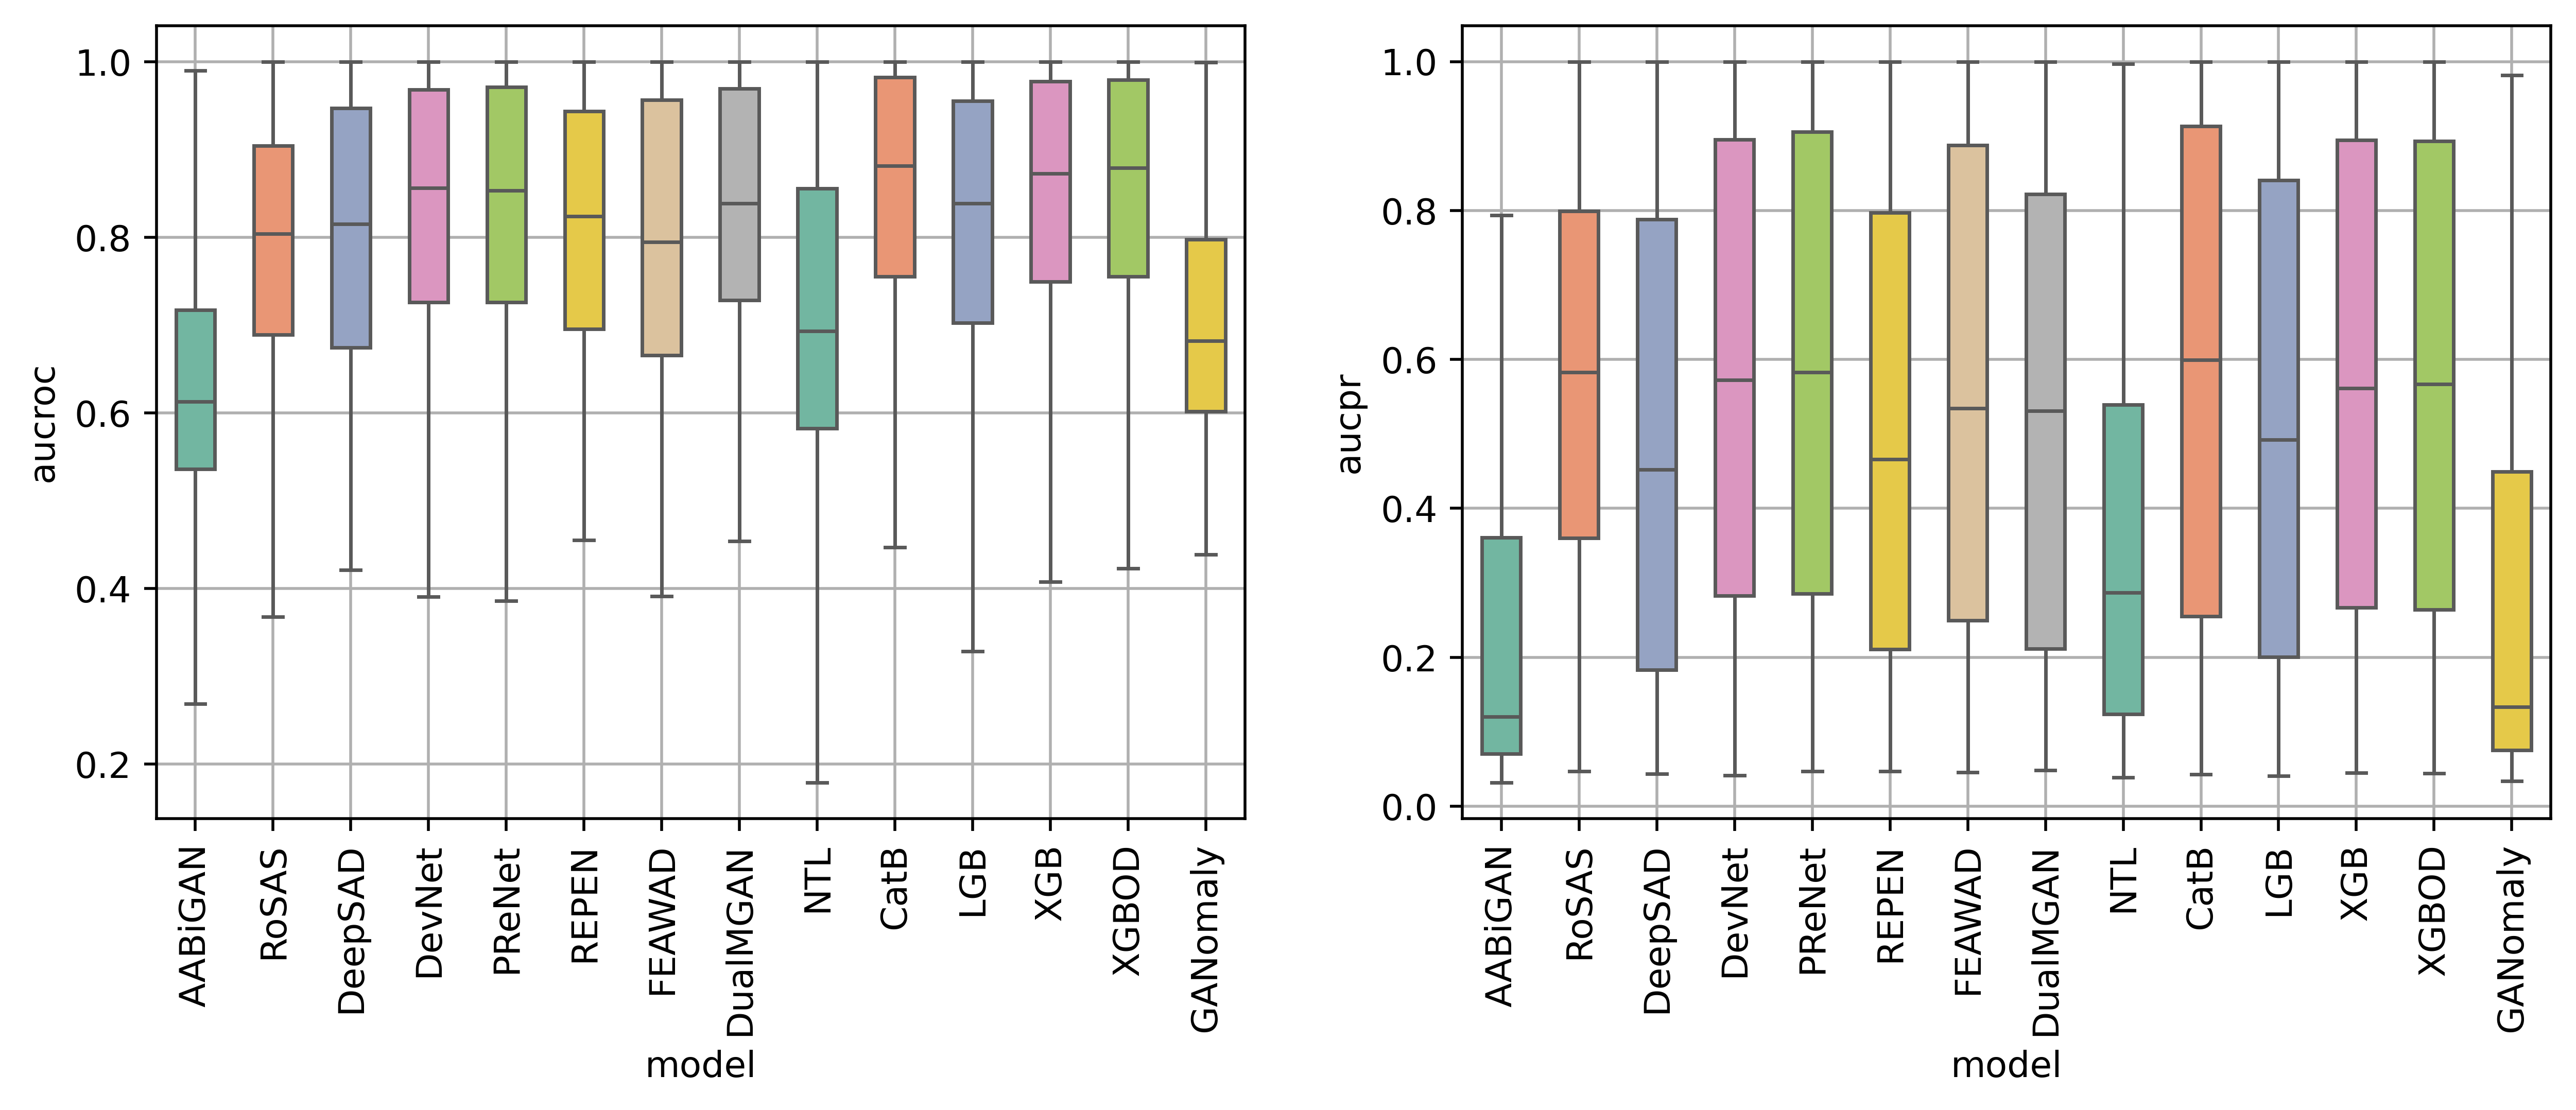

In [3]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt



tabular_detail = pd.read_excel("/data/coding/wsad/new_wzb/WSADBench/results/tabular_CV_by_ViT/summary/summary_CV_ViT.xlsx",
                                sheet_name="详细结果").dropna(subset=["model", "dataset", "aucroc", "aucpr"])

# method_order = ["AABiGAN","AABiGAN_eln_0.5","AABiGAN_eln_1.0","TargAD_AC3","TargAD_eln_0.5","TargAD_eln_1.0","DualMGAN","DualMGAN_eln_0.5","DualMGAN_eln_1.0"]
# model_names = ["AABiGAN","AABiGAN_eln_0.5","AABiGAN_eln_1.0","TargAD_AC3","TargAD_eln_0.5","TargAD_eln_1.0","DualMGAN","DualMGAN_eln_0.5","DualMGAN_eln_1.0"]
method_order = ["AABiGAN","RoSAS","DeepSAD", "DevNet", "PReNet", "REPEN", "FEAWAD","DualMGAN","NTL","CatB","LGB","XGB","XGBOD","GANomaly"]
hew_order = ['tabular_classical']
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=500)
ax = axes[0]
sns.boxplot(
    data=tabular_detail,
    x="model",
    y="aucroc",
    # hue="model",
    palette="Set2",
    fliersize=0,
    width=0.5,
    showfliers=False,
    ax=ax,
    order=method_order,
    hue_order=hew_order,
    # boxprops=dict(linewidth=1.0),
    # medianprops=dict(linewidth=1.2),
    # whiskerprops=dict(linewidth=1.0),
    # capprops=dict(linewidth=1.0),
)
ax.grid()
ax.tick_params(axis='x', rotation=90)

ax = axes[1]
sns.boxplot(
    data=tabular_detail,
    x="model",
    y="aucpr",
    # hue="model",
    palette="Set2",
    fliersize=0,
    width=0.5,
    showfliers=False,
    ax=ax,
    order=method_order,
    hue_order=hew_order,
    # boxprops=dict(linewidth=1.0),
    # medianprops=dict(linewidth=1.2),
    # whiskerprops=dict(linewidth=1.0),
    # capprops=dict(linewidth=1.0),
)

ax.grid()
ax.tick_params(axis='x', rotation=90)
